In [47]:
import numpy as np, matplotlib.pyplot as plt
import defs, propagation

# 1. Set up computational geometry.
The following parameters can be adjusted to check maps over different domains. Setting too small of a z-range may affect the stability of the refracted model, which requires a large distance to trace rays.  

Positive z-values indicate air regions, while negative z-values indicate ice regions. The analytic solutions included in this repository have a source set to 95 meters below the ice surface, which means that `tx_z` must be set to `-95` for the comparison in [3.2](#32-compare-with-analytic-solutions) to make sense. Setting a different source will still result in successful map generation, just not a reasonable comparison.

In [48]:
rmax = 1000 # rmin always assumed 0
zmin, zmax = -1000, 500   # need a few meters of air above surface as a numerical tolerance
dr, dz = 1, 1
tx_z = -95

# Do not change these lines
tx_pos = np.array([0, tx_z])
npts_r, npts_z = int(rmax / dr) + 1, int((zmax - zmin) / dz) + 1
ior, grad_ior = defs.ior_exp1, defs.grad_ior_exp1

# 2. Run solver and save results.
The user has a choice as to the number of "big rays" used to calculate refracted maps. The solutions become more accurate as the number of big rays increases, with the caveat that at a fixed step size, increasing the number of big rays too much will result in numerical instability. A good rule of thumb is to make sure $$dr, dz \le \frac{10}{\text{number of big rays}}$$

so at 10 big rays, 1m is a safe step size; at 20 big rays, 0.5m, etc.

In [49]:
n_big_rays = 10

ttc = propagation.TravelTimeCalculator(tx_z, zmin, zmax, rmax, npts_z, npts_r)
ttc.set_ior_and_solve(ior, grad_ior, n_big_rays)
print(ttc.travel_time_fields)

ttc.to_npz('tt_maps')

{'early': <pykonal.fields.ScalarField3D object at 0x77d9dc280>, 'late': <pykonal.fields.ScalarField3D object at 0x77d9ded00>}


# 3. Visualize & assess results!

## 3.1. Absolute travel-time visualization
We've generated two maps here: first and second arrival times for each point in the domain. At this point, you should have `tt_maps_early.npz` and `tt_maps_late.npz` files saved. The following code shows how to unpack the results (which would then typically be used in an interferometric reconstruction of signal arrival direction) and plot them.

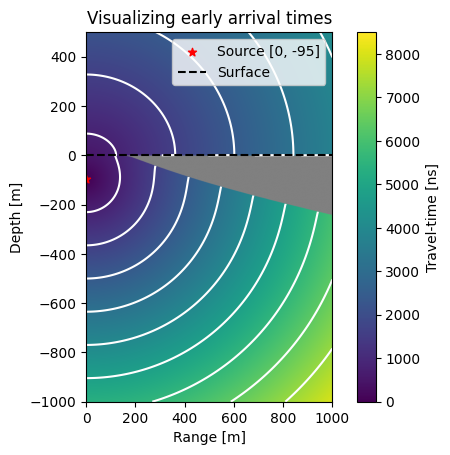

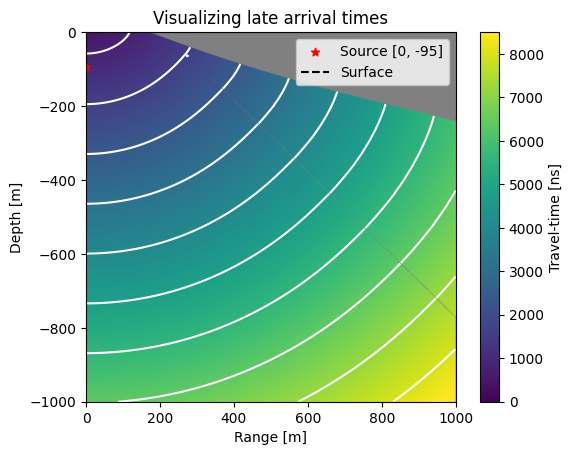

In [50]:
cmap = plt.get_cmap('viridis')
cmap.set_bad('grey')    # Better visualization of shadow zone
clim = 0, 8500

for comp in ['early', 'late']:
    
    fig, ax = plt.subplots()

    # Unpack relevant results
    ttc_output = np.load(f'tt_maps_{comp}.npz') # Load npz file
    rvals, zvals = ttc_output['r_range_vals'], ttc_output['z_range_vals']
    if comp == 'late':
        zvals = zvals[:-zmin // dz + 1]
    tvals = ttc_output['data']
    src_z = ttc_output['antennaz']

    # Plot the travel-time map!
    tvals = np.flip(np.swapaxes(np.squeeze(tvals), 0, 1), axis = 0)
    im = ax.imshow(tvals, cmap, extent = [rvals[0], rvals[-1], zvals[0], zvals[-1]])
    im.set_clim(clim)
    cbar = fig.colorbar(im)
    cbar.set_label('Travel-time [ns]')
    ax.scatter(0, src_z, marker = '*', label = f'Source [0, {src_z}]', color = 'red')
    
    ax.contour(rvals, np.flip(zvals), tvals, levels = 10, colors = 'white')
    ax.hlines(0, rvals[0], rvals[-1], linestyles = '--', colors = 'black', label = 'Surface')
    ax.set_xlabel('Range [m]')
    ax.set_ylabel('Depth [m]')
    ax.legend()
    ax.set_title(f'Visualizing {comp} arrival times')

## 3.2. Compare with analytic solutions.
As mentioned above, this part assumes your source has been placed 95 meters below the ice surface. The analytic maps are generated with coordinates from (-999, 0) to (1000, 1), so depending on the parameters of the numerical map some alignment needs to be done.

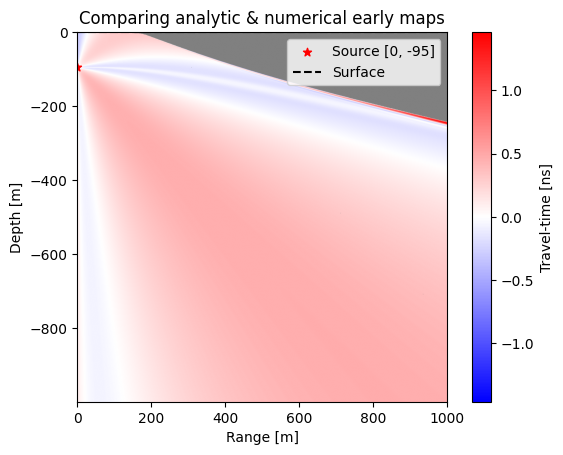

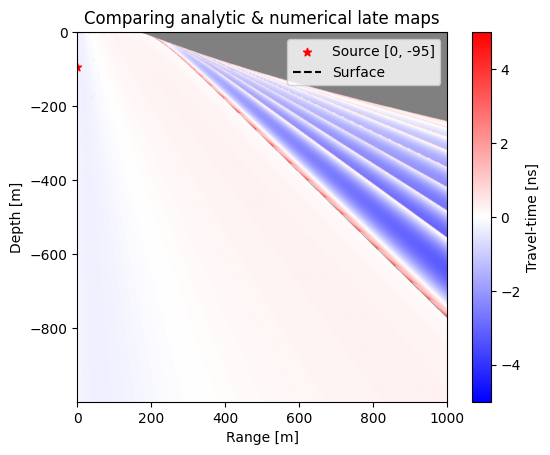

In [51]:
cmap = plt.get_cmap('bwr')
cmap.set_bad('grey')

for comp in ['early', 'late']:

    fig, ax = plt.subplots()

    an_tvals = np.load(f'analytic_{comp}.npy')

    # Unpack relevant results
    ttc_output = np.load(f'tt_maps_{comp}.npz')
    rvals, zvals = ttc_output['r_range_vals'], ttc_output['z_range_vals']
    if comp == 'late':
        zvals = zvals[:-zmin // dz + 1]
    tvals = np.squeeze(ttc_output['data'])
    src_z = ttc_output['antennaz']

    # Align maps (rvals)
    tvals = tvals[:1000]
    an_tvals = an_tvals[:rmax + 1]

    # Align maps (zvals)
    an_zvals = np.linspace(-999, 1, 1000)
    an_mask = np.logical_and(an_zvals >= zmin, an_zvals <= zmax)
    an_zvals = an_zvals[an_mask]
    an_tvals = an_tvals[:, an_mask]

    fmm_mask = np.logical_and(zvals >= -999, zvals < 1)
    zvals = zvals[fmm_mask]
    tvals = tvals[:, fmm_mask]

    if dr > 1:
        an_tvals = an_tvals[::dr]
    elif dr < 1:
        tvals = tvals[::int(1/dr)]
    if dz > 1:
        an_tvals = an_tvals[:, ::dz]
    elif dz < 1:
        tvals = tvals[:, ::int(1/dz)]

    # Plot the comparison map!
    comparison = np.flip(np.swapaxes(an_tvals - tvals, 0, 1), axis = 0)
    im = ax.imshow(comparison, cmap, extent = [rvals[0], rvals[-1], zvals[0], zvals[-1]])
    
    if comp == 'early':
        clim = np.nanmax(np.abs(comparison[np.isfinite(comparison)]))
        im.set_clim(-clim, clim)
    else:
        im.set_clim(-5, 5)
    cbar = fig.colorbar(im)
    cbar.set_label('Travel-time [ns]')
    ax.scatter(0, src_z, marker = '*', label = f'Source [0, {src_z}]', color = 'red')
    ax.hlines(0, rvals[0], rvals[-1], linestyles = '--', colors = 'black', label = 'Surface')
    ax.set_xlabel('Range [m]')
    ax.set_ylabel('Depth [m]')
    ax.legend()
    ax.set_title(f'Comparing analytic & numerical {comp} maps')